In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import Image as IPImage

# TensorFlow & Keras (Unified Imports)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, optimizers
from tensorflow.keras.models import Sequential, model_from_json
from tensorflow.keras.layers import (
    Flatten, Dense, Activation, Dropout, Conv2D, MaxPooling2D
)
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Applications (Pre-trained models)
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input as densenet_preprocess

# Scikit-learn
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.18.0


### Read Dataset

**Directory Names Containing Training Data**

In [3]:
# Define the path to the directory containing the images for training
train_data = '/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT'

# Create a Pandas DataFrame with a single column
# The column is populated with the list of file/directory names in the 'train_data' directory
pd.DataFrame(
    os.listdir(train_data),
    columns=['File Name']
)

,File Name
0,benign
1,normal
2,malignant


**Directory Paths Containing Training Data**

In [4]:
# Get a list of the file paths in the 'train_data' directory
train_files = [i for i in glob.glob(train_data + "/*/*")]

# Randomly shuffle the list of file paths
np.random.shuffle(train_files)

# Extract labels from the directory names of each file path
labels = [os.path.dirname(i).split("/")[-1] for i in train_files]

# Combine file paths & its corresponding labels into a list of tuples
data = zip(train_files, labels)

# Create a Pandas DataFrame with 2 columns
# "Path" column contains file paths, & "Label" column contains corresponding labels
training_data = pd.DataFrame(data, columns=["Path", "Label"])

# Display the contents of the DataFrame
training_data

,Path,Label
0,/kaggle/input/breast-ultrasound-images-dataset...,normal
1,/kaggle/input/breast-ultrasound-images-dataset...,normal
2,/kaggle/input/breast-ultrasound-images-dataset...,benign
3,/kaggle/input/breast-ultrasound-images-dataset...,benign
4,/kaggle/input/breast-ultrasound-images-dataset...,normal
...,...,...
1573,/kaggle/input/breast-ultrasound-images-dataset...,benign
1574,/kaggle/input/breast-ultrasound-images-dataset...,benign
1575,/kaggle/input/breast-ultrasound-images-dataset...,malignant
1576,/kaggle/input/breast-ultrasound-images-dataset...,normal


### Data Visualization

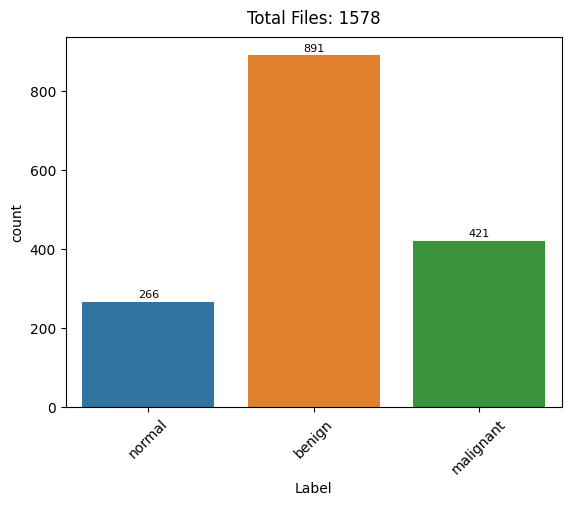

In [5]:
# Create a countplot() using Seaborn, where x-axis represents the "Label" column of the training_data DataFrame
ax = sns.countplot(x=training_data["Label"])

# Display count inside each bar as integers
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=8)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Add a title with the total count of files
plt.title(f'Total Files: {len(training_data)}', pad=10)

# Show the plot
plt.show()

### Collect Data Paths & Labels from Directory Structure

In [6]:
data_paths = []
labels = []

main_dirs = os.listdir(train_data)
for folder_name in main_dirs:
    folder_path = os.path.join(train_data, folder_name)
    files = os.listdir(folder_path)
    for file in files:
        file_path = os.path.join(folder_path, file)
        data_paths.append(file_path)
        labels.append(folder_name)

### Data Preprocessing

In [7]:
# Set the batch size for training
batch_size = 16

# Define the target image size for preprocessing
image_size = (256, 256)

# Specify the number of color channels in the images (3 for RGB)
num_channels = 3

# Create the image shape tuple based on the specified size and channels
image_shape = (image_size[0], image_size[1], num_channels)

# Create a Pandas Series containing file paths with the name 'Path'
data_dirs = pd.Series(data_paths, name='Path')

# Create a Pandas Series containing corresponding labels with the name 'Label'
classes = pd.Series(labels, name='Label')

def preprocess_image(img):
    return img

# Split the data into training and validation-test sets
train_df, val_test_df = train_test_split(
    training_data, 
    train_size=0.8, 
    shuffle=True, 
    random_state=123
)

# Further split the validation-test set into validation and test sets
val_df, test_df = train_test_split(
    val_test_df, 
    train_size=0.5, 
    shuffle=True, 
    random_state=123
)

# ImageDataGenerator configuration
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image, 
    rescale=1.0/255
)

# Convert the 'Label' column to string type
train_df['Label'] = train_df['Label'].astype(str)
val_df['Label'] = val_df['Label'].astype(str)

# Create generators for training, validation, and testing
train_generator = datagen.flow_from_dataframe(
    train_df, 
    x_col='Path', 
    y_col='Label',
    target_size=image_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size
)

valid_generator = datagen.flow_from_dataframe(
    val_df, 
    x_col='Path', 
    y_col='Label',
    target_size=image_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size
)

Found 1262 validated image filenames belonging to 3 classes.
Found 158 validated image filenames belonging to 3 classes.


**Display Class Names**

In [8]:
# Get the class indices (mapping of the class names to numerical indices) from the training generator
class_indices = train_generator.class_indices

# Display the keys (class names) from the class_indices dictionary
class_indices.keys()

dict_keys(['benign', 'malignant', 'normal'])

In [9]:
# Initialize an empty list to store class labels
labels = []

# Iterate through the keys (class names) in the class_indices dictionary
for key in class_indices.keys():
    labels.append(key)  # Append each class name to the labels list

# Calculate the total no. of unique labels
total_labels = len(labels)

# Print the list of class labels and the total no. of unique labels
print("Labels: ", labels)
print("\nTotal no. of unique labels:", total_labels)

Labels:  ['benign', 'malignant', 'normal']

Total no. of unique labels: 3


**Visualize a Subset of Images from the Training Set**

(574, 776, 3)
(471, 550, 3)
(576, 772)
(583, 626)
(477, 509, 3)
(578, 766, 3)
(494, 545)
(576, 615, 3)


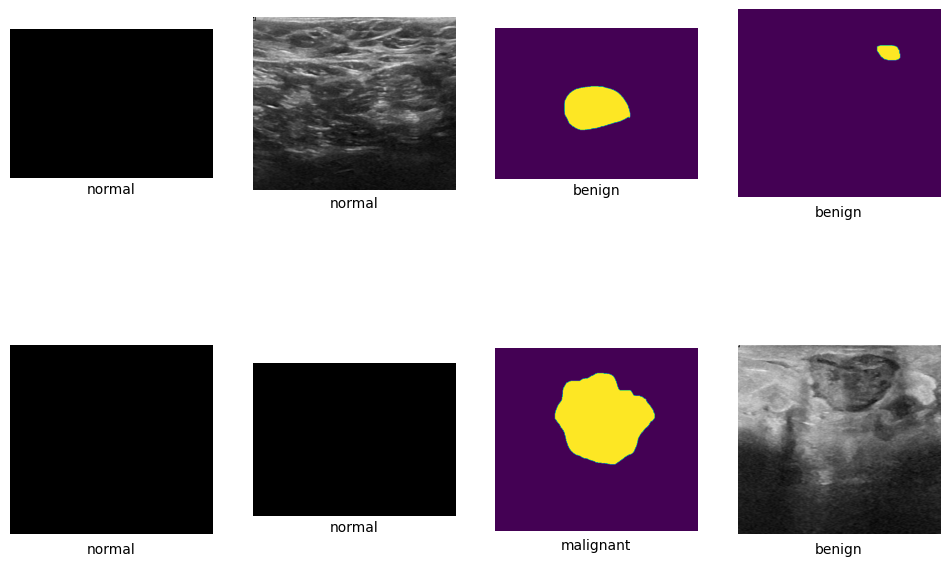

In [10]:
# Set the number of rows and columns for the subplot grid
no_of_rows = 2
no_of_columns = 4

# Create a subplot grid with the specified number of rows and columns
fig, axes = plt.subplots(no_of_rows, no_of_columns, figsize=(12, 8))

# Iterate through the rows
for i in range(no_of_rows):
    # Iterate through the columns
    for j in range(no_of_columns):
        # Calculate the index for accessing the data
        index = i * no_of_columns + j

        # Check if the index is within the bounds of the data
        if index < len(training_data):

            # Open the image using the PIL library
            im = Image.open(training_data.iloc[index]['Path'])

            # Convert the PIL image to a NumPy array
            img = np.array(im)

            # Print the shape of the image array
            print(img.shape)

            # Display the image on the subplot at position (i, j)
            axes[i, j].imshow(img)

            # Turn off axis labels for better visualization
            axes[i, j].axis('off')

            # Get the label for the current image and display it as text
            label = training_data.iloc[index]['Label']
            axes[i, j].text(0.5, -0.1, label, ha='center', transform=axes[i, j].transAxes)

# Show the entire subplot grid
plt.show()

### Build Model

In [11]:
# Load DenseNet-121 with pre-trained weights
base_model = DenseNet121(
    weights='/kaggle/input/densenet121-weights/densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5',
    include_top=False, 
    input_shape=(256, 256, 3)
)

# Freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

# Create model
model = Sequential()

# Add the pre-trained DenseNet-121 base model
model.add(base_model)

# Flatten the output of the base model
model.add(Flatten())

# Add fully connected layers with dropout for regularization
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))

# Additional layers for classification
model.add(Dense(128, activation='relu'))
model.add(Dense(3, activation='softmax'))

# Display the summary of the model architecture
model.summary()

2025-11-29 22:00:30.454286: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    67,109,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,787,843 (289.11 MB)

 Trainable params: 68,750,339 (262.26 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

**Visualize the Neural Network Architecture**

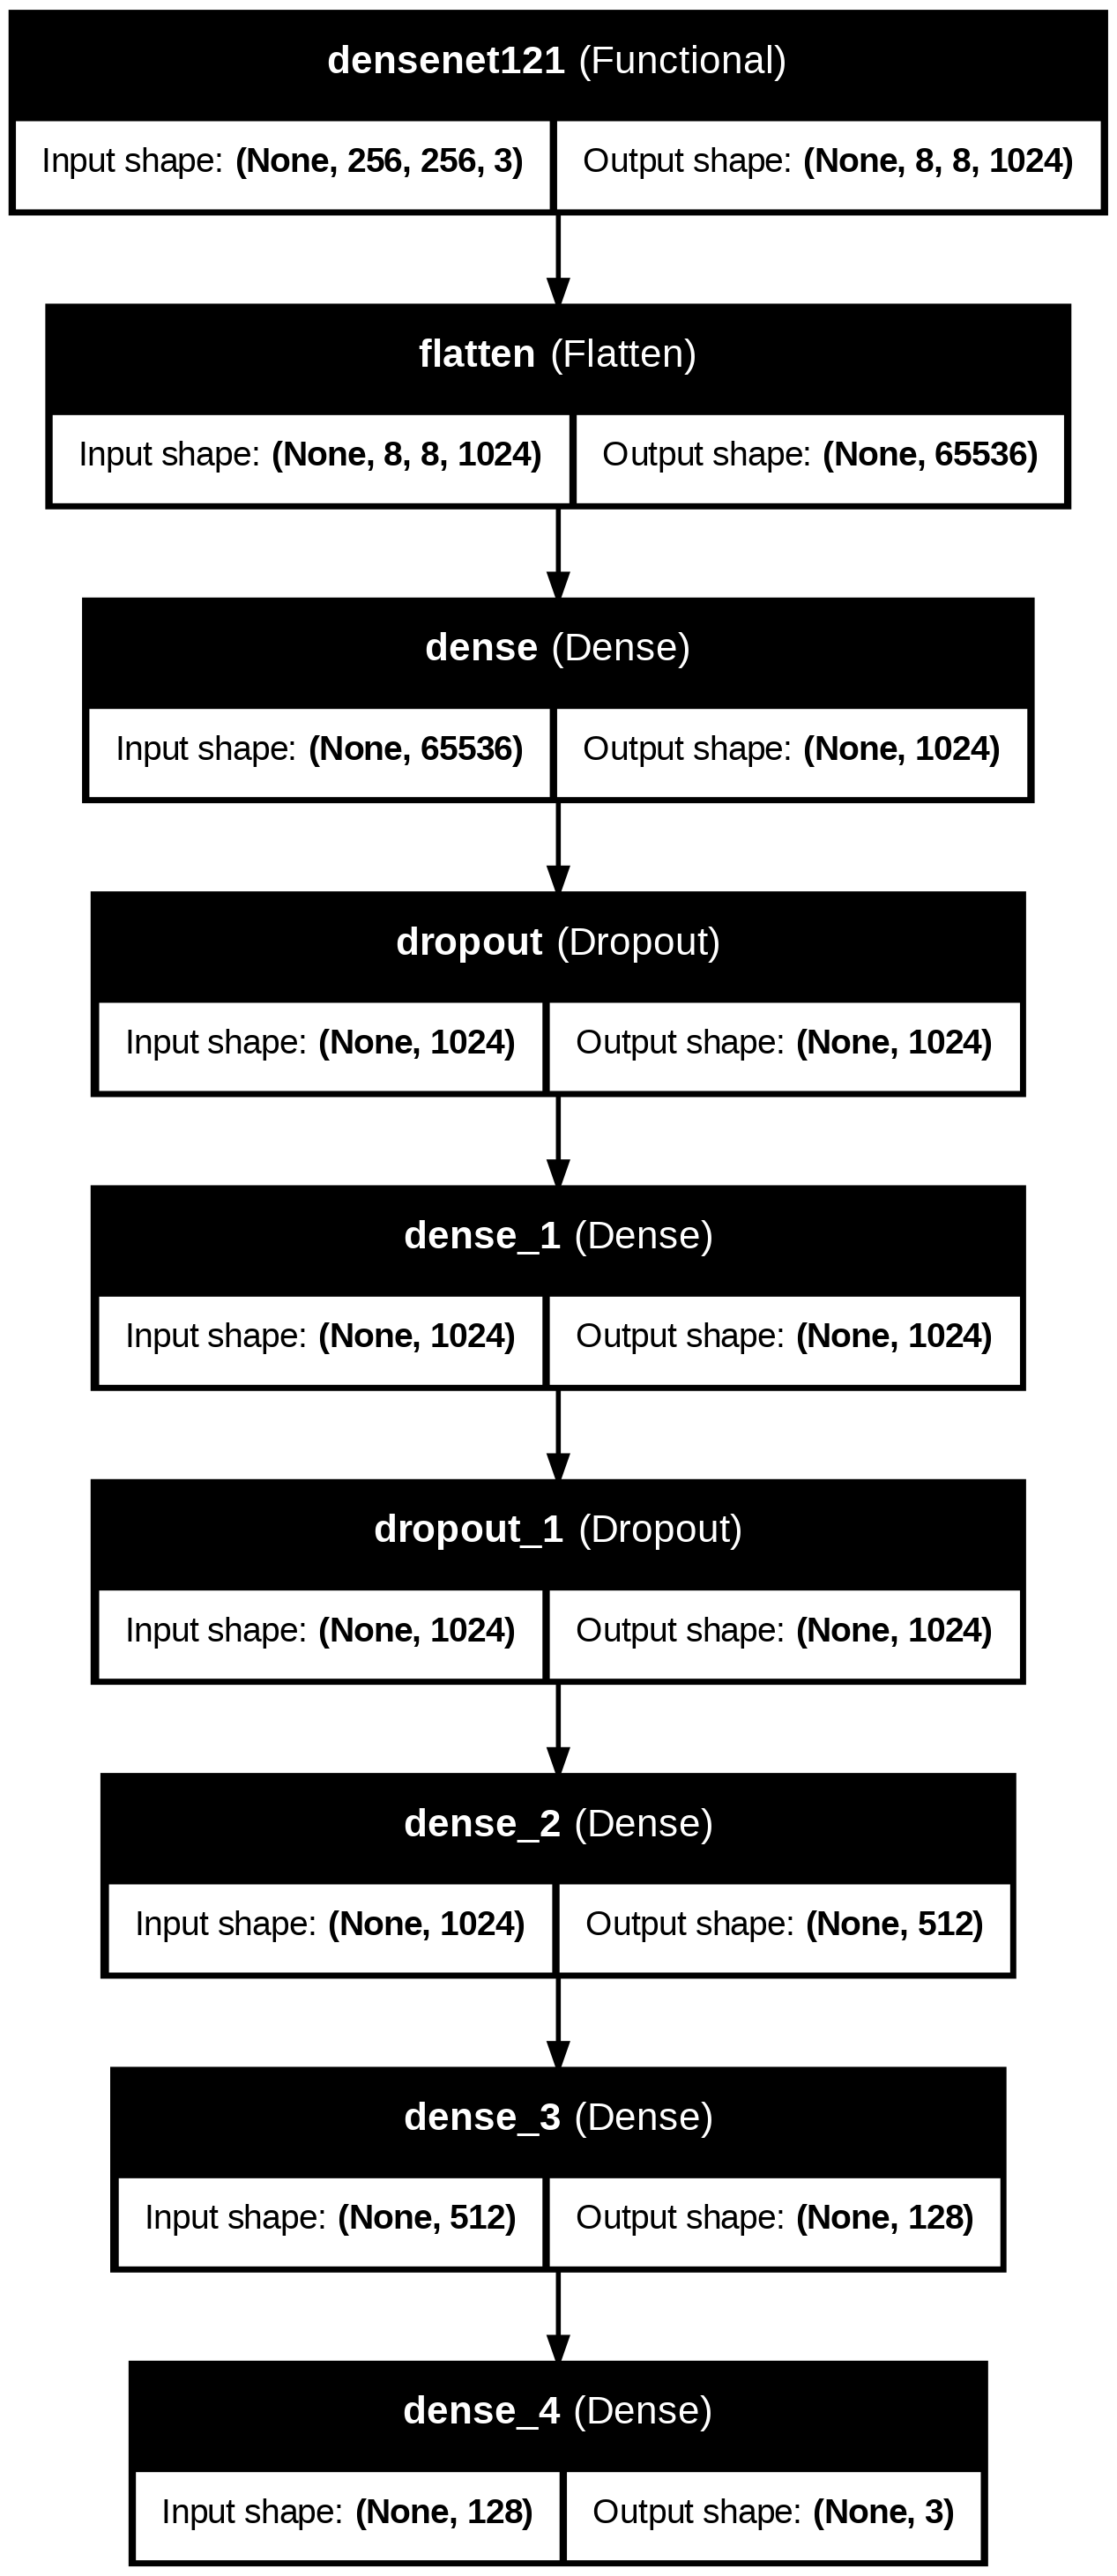

In [12]:
# Specify the file path for saving the visualization image
model_visualization_path = "/kaggle/working/nn_architecture.png"

# Plot the model and save the visualization image
plot_model(model, to_file=model_visualization_path, show_shapes=True, show_layer_names=True)

# Display the visualization image
IPImage(filename=model_visualization_path)

**Create Model Checkpoint Callback to Save Best Model**

In [13]:
# Define the path to save the best model checkpoint
checkpoint_path = "/kaggle/working/model.h5"

# Create a ModelCheckpoint callback
# This callback saves the model when validation accuracy improves
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',  # Monitor validation accuracy
    save_best_only=True,     # Save only the best model
    mode='max',              # Save based on the maximum validation accuracy
    verbose=1                # Display progress information
)                

### Compile Model

In [14]:
# Compile the model with the Adam optimizer, categorical crossentropy loss, and accuracy metric
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Categorical crossentropy loss for multi-class classification
    metrics=['accuracy']              # Monitor accuracy during training
)              

### Train Model

In [15]:
# Train the model using the fit() method
history = model.fit(
    train_generator,                                   # Training data generator
    steps_per_epoch=train_generator.samples // train_generator.batch_size,  # Number of steps per epoch
    epochs=15,                                         # Number of training epochs
    validation_data=valid_generator,                   # Validation data generator
    validation_steps=valid_generator.samples // valid_generator.batch_size,  # Number of validation steps
    callbacks=[checkpoint]                             # List of callbacks, including the ModelCheckpoint
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5120 - loss: 7.8463
Epoch 1: val_accuracy improved from -inf to 0.79861, saving model to /kaggle/working/model.h5


78/78 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 0.5132 - loss: 7.7950 - val_accuracy: 0.7986 - val_loss: 0.4516
Epoch 2/15
 1/78 ━━━━━━━━━━━━━━━━━━━━ 3:11 2s/step - accuracy: 0.8125 - loss: 0.2882

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.79861 to 0.84028, saving model to /kaggle/working/model.h5


...

78/78 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.8241 - loss: 0.4346 - val_accuracy: 0.8611 - val_loss: 0.3710
Epoch 6/15
 1/78 ━━━━━━━━━━━━━━━━━━━━ 3:23 3s/step - accuracy: 0.9375 - loss: 0.3409
Epoch 6: val_accuracy improved from 0.86111 to 0.86806, saving model to /kaggle/working/model.h5


78/78 ━━━━━━━━━━━━━━━━━━━━ 41s 498ms/step - accuracy: 0.9375 - loss: 0.3409 - val_accuracy: 0.8681 - val_loss: 0.3769
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8714 - loss: 0.3233
Epoch 7: val_accuracy did not improve from 0.86806
78/78 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.8714 - loss: 0.3234 - val_accuracy: 0.8472 - val_loss: 0.3511
Epoch 8/15
 1/78 ━━━━━━━━━━━━━━━━━━━━ 3:04 2s/step - accuracy: 1.0000 - loss: 0.1240
Epoch 8: val_accuracy did not improve from 0.86806
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 241ms/step - accuracy: 1.0000 - loss: 0.1240 - val_accuracy: 0.8681 - val_loss: 0.3191
Epoch 9/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9012 - loss: 0.2741
Epoch 9: val_accuracy did not improve from 0.86806
78/78 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.9012 - loss: 0.2741 - val_accuracy: 0.8542 - val_loss: 0.3653
Epoch 10/15
 1/78 ━━━━━━━━━━━━━━━━━━━━ 3:14 3s/step - accuracy: 0.9375 - loss: 0.1350
Epoch 10: val_accuracy did not improve fro

78/78 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.9114 - loss: 0.2486 - val_accuracy: 0.8889 - val_loss: 0.3019
Epoch 12/15
 1/78 ━━━━━━━━━━━━━━━━━━━━ 3:06 2s/step - accuracy: 0.8125 - loss: 0.3178
Epoch 12: val_accuracy did not improve from 0.88889
78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - accuracy: 0.8125 - loss: 0.3178 - val_accuracy: 0.8472 - val_loss: 0.3380
Epoch 13/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9008 - loss: 0.2360
Epoch 13: val_accuracy improved from 0.88889 to 0.89583, saving model to /kaggle/working/model.h5


78/78 ━━━━━━━━━━━━━━━━━━━━ 238s 3s/step - accuracy: 0.9009 - loss: 0.2358 - val_accuracy: 0.8958 - val_loss: 0.3417
Epoch 14/15
 1/78 ━━━━━━━━━━━━━━━━━━━━ 3:35 3s/step - accuracy: 1.0000 - loss: 0.0245
Epoch 14: val_accuracy did not improve from 0.89583
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 234ms/step - accuracy: 1.0000 - loss: 0.0245 - val_accuracy: 0.8889 - val_loss: 0.3618
Epoch 15/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9370 - loss: 0.1593
Epoch 15: val_accuracy improved from 0.89583 to 0.93056, saving model to /kaggle/working/model.h5


78/78 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.9370 - loss: 0.1593 - val_accuracy: 0.9306 - val_loss: 0.2027


**Display Training History**

In [16]:
# Create a Pandas DataFrame containing the training history (metrics) of the model
train_history = pd.DataFrame(history.history)

# Add a new column 'Epoch' with values from 1 to the number of epochs
train_history['Epoch'] = range(1, len(train_history) + 1)

# Reorder columns for clarity
train_history = train_history[['Epoch', 'loss', 'accuracy', 'val_loss', 'val_accuracy']]

# Display the DataFrame
train_history

,Epoch,loss,accuracy,val_loss,val_accuracy
0,1,3.791693,0.606742,0.451594,0.798611
1,2,0.288223,0.812500,0.436986,0.840278
2,3,0.542420,0.780899,0.373217,0.833333
3,4,0.591964,0.687500,0.386819,0.826389
4,5,0.405138,0.833868,0.371036,0.861111
5,6,0.340910,0.937500,0.376870,0.868056
6,7,0.332095,0.870786,0.351089,0.847222
7,8,0.123963,1.000000,0.319132,0.868056
8,9,0.270664,0.897271,0.365281,0.854167
9,10,0.134988,0.937500,0.336068,0.868056


### Evaluate Model (Train & Validation Set)

In [17]:
# Evaluate the model on the train set
train_loss, train_accuracy = model.evaluate(train_generator, steps=train_generator.samples // train_generator.batch_size)

# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(valid_generator, steps=valid_generator.samples // valid_generator.batch_size)

# Convert accuracy to percentage
train_accuracy_percentage = train_accuracy * 100
val_accuracy_percentage = val_accuracy * 100

# Create a Pandas DataFrame to display the results
evaluation_results = pd.DataFrame({
    'Set': ['Train', 'Validation'],
    'Loss': [train_loss, val_loss],
    'Accuracy': [f'{train_accuracy_percentage:.2f}%', f'{val_accuracy_percentage:.2f}%']
})

# Display the evaluation results DataFrame
evaluation_results

78/78 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9853 - loss: 0.0603
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8894 - loss: 0.3211


,Set,Loss,Accuracy
0,Train,0.071764,98.00%
1,Validation,0.256128,90.97%


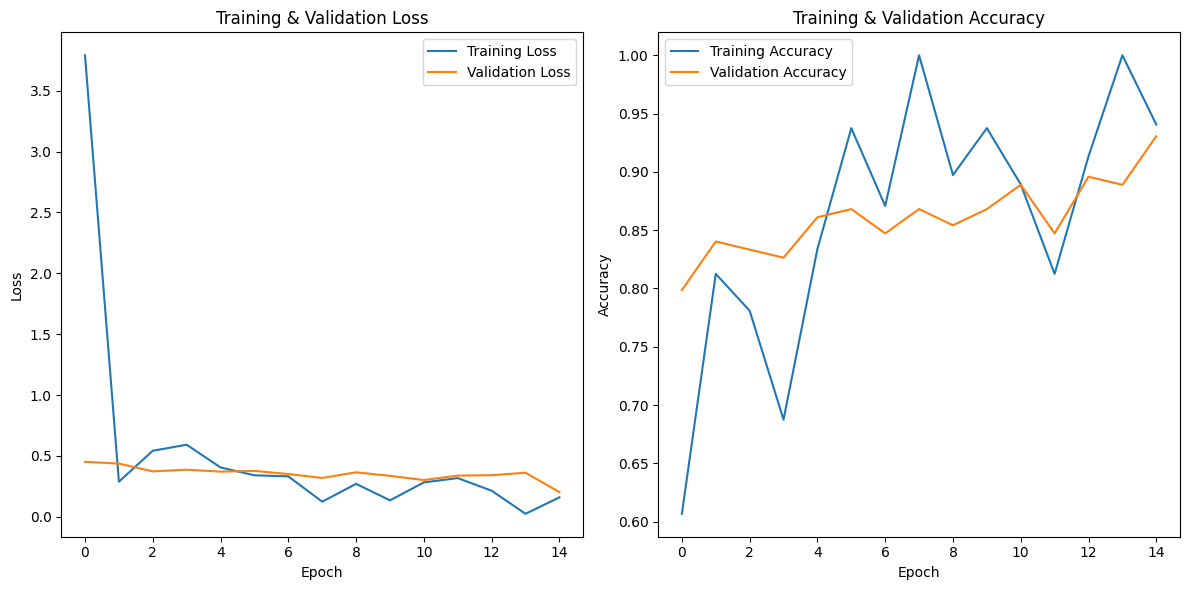

In [18]:
# Plotting the training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_history['loss'], label='Training Loss')
plt.plot(train_history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_history['accuracy'], label='Training Accuracy')
plt.plot(train_history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()